<a href="https://colab.research.google.com/github/SuyogPatgave/Python_Codes-Projects/blob/main/CRM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import and View


Importing library packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

Data Import

In [ ]:
acc= pd.read_csv('/content/accounts.csv')
data_dic = pd.read_csv('/content/data_dictionary.csv')
prdts = pd.read_csv('/content/products.csv')
sales_pipe = pd.read_csv('/content/sales_pipeline.csv')
sales_team = pd.read_csv('/content/sales_teams.csv')

In [ ]:
pd.set_option('display.width', 300)
pd.set_option('display.max_columns', None)

Consolidating all datasets (assigning names for referential convenience) in one list

In [ ]:
datasets = [('accounts', acc), ('data dictionary', data_dic), ('products', prdts), ('sales pipeline', sales_pipe), ('sales team', sales_team)]

Data Visibility

In [ ]:
for name, dataset in datasets:
  print(f"\n\n\n{name.title()}:")
  print(dataset.head(10))
  print(f"--Dimensions: {dataset.shape}")




Accounts:
            account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation      technolgy              1996  1100.04       2822   United States               NaN
1        Betasoloin        medical              1999   251.41        495   United States               NaN
2          Betatech        medical              1986   647.18       1185           Kenya               NaN
3        Bioholding        medical              2012   587.34       1356      Philipines               NaN
4           Bioplex        medical              1991   326.82       1016   United States               NaN
5          Blackzim         retail              2009   497.11       1588   United States               NaN
6     Bluth Company      technolgy              1993  1242.32       3027   United States  Acme Corporation
7        Bubba Gump       software              2002   987.39       2253   United States               NaN
8           Cancity     

Data Description

In [ ]:
  for name, dataset in datasets:
    print(f"\n\n\n{name.title()}:")
    print(dataset.describe())




Accounts:
       year_established       revenue     employees
count         85.000000     85.000000     85.000000
mean        1996.105882   1994.632941   4660.823529
std            8.865427   2169.491436   5715.601198
min         1979.000000      4.540000      9.000000
25%         1989.000000    497.110000   1179.000000
50%         1996.000000   1223.720000   2769.000000
75%         2002.000000   2741.370000   5595.000000
max         2017.000000  11698.030000  34288.000000



Data Dictionary:
                 Table    Field   Description
count               21       21            21
unique               4       18            19
top     sales_pipeline  account  Company name
freq                 8        2             2



Products:
        sales_price
count      7.000000
mean    6023.571429
std     9388.428070
min       55.000000
25%      823.000000
50%     3393.000000
75%     5151.500000
max    26768.000000



Sales Pipeline:
        close_value
count   6711.000000
mean    1490.9155

# Data Pre-Processing

Account Table

In [ ]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,NaN
81,Zencorporation,technolgy,2011,40.79,142,China,NaN
82,Zoomit,entertainment,1992,324.19,978,United States,NaN
83,Zotware,software,1979,4478.47,13809,United States,NaN


In [ ]:
acc_cols = acc[['account', 'sector', 'office_location', 'subsidiary_of']]

In [ ]:
def short_summary(df):
  for columns in df:
      print(f"\n\n\nColumn Name: {df[columns].name}")
      print(df[columns].value_counts())
      print(f"Number of Null values: {df[columns].isnull().sum()}")
      print(f"Dimensions--{df.shape}")
      print(f"Data type: {df[columns].dtype}")

In [ ]:
'''for columns in acc_cols:
  print(f"\n\n\nColumn Name: {acc_cols[columns].name}")
  print(f"Number of Null values: {acc_cols[columns].isnull().sum()}")
  print(acc_cols[columns].value_counts())'''
short_summary(acc_cols)




Column Name: account
account
Acme Corporation    1
Betasoloin          1
Betatech            1
Bioholding          1
Bioplex             1
                   ..
Zathunicon          1
Zencorporation      1
Zoomit              1
Zotware             1
Zumgoity            1
Name: count, Length: 85, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: sector
sector
retail                17
technolgy             12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: office_location
office_location
United States    71
Kenya             1
Philipines        1
Japan             1
Italy             1
Norway            1
Korea             1
Jordan            1
Brazil            1
Germany           1
Panama  

In [ ]:
acc.subsidiary_of =  acc.subsidiary_of.fillna('Not a Subsidiary')
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


Products Table

In [ ]:
acc['sector']= acc['sector'].astype('category')

In [ ]:
prdts

,product,series,sales_price
0,GTX Basic,GTX,550
1,GTX Pro,GTX,4821
2,MG Special,MG,55
3,MG Advanced,MG,3393
4,GTX Plus Pro,GTX,5482
5,GTX Plus Basic,GTX,1096
6,GTK 500,GTK,26768


Sales Pipeline

In [ ]:
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN


In [ ]:
sales_pipe_cols = sales_pipe[['sales_agent', 'product', 'account', 'deal_stage']]

In [ ]:
'''for values in sales_pipe_cols:
  print(f"\n\n\n{values}")
  print(f"Number of Null values: {sales_pipe_cols[values].isnull().sum()}")
  print(sales_pipe_cols[values].value_counts())'''

short_summary(sales_pipe_cols)




Column Name: sales_agent
sales_agent
Darcel Schlecht       747
Vicki Laflamme        451
Anna Snelling         448
Kary Hendrixson       438
Kami Bicknell         362
Versie Hillebrand     361
Zane Levy             349
Cassey Cress          346
Jonathan Berthelot    345
Gladys Colclough      317
Lajuana Vencill       311
Corliss Cosme         310
Markita Hansen        306
Maureen Marcano       285
Marty Freudenburg     281
Donn Cantrell         275
James Ascencio        267
Violet Mclelland      261
Moses Frase           260
Daniell Hammack       259
Niesha Huffines       239
Reed Clapper          237
Boris Faz             210
Cecily Lampkin        203
Hayden Neloms         202
Elease Gluck          177
Rosalina Dieter       160
Rosie Papadopoulos    160
Garret Kinder         123
Wilburn Farren        110
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(8800, 4)
Data type: object



Column Name: product
product
GTX Basic         1866
MG Special        1651
GTXPro     

In [ ]:
#Converting date values to date data type, converting from string/object

sales_pipe['close_date'] = pd.to_datetime(sales_pipe['close_date'])
sales_pipe['engage_date'] = pd.to_datetime(sales_pipe['engage_date'])


#Converting Deal stage to factor/category

sales_pipe['deal_satge'] = sales_pipe['deal_stage'].astype('category')

In [ ]:
sales_pipe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   opportunity_id  8800 non-null   object        
 1   sales_agent     8800 non-null   object        
 2   product         8800 non-null   object        
 3   account         7375 non-null   object        
 4   deal_stage      8800 non-null   object        
 5   engage_date     8300 non-null   datetime64[ns]
 6   close_date      6711 non-null   datetime64[ns]
 7   close_value     6711 non-null   float64       
 8   deal_satge      8800 non-null   category      
dtypes: category(1), datetime64[ns](2), float64(1), object(5)
memory usage: 558.9+ KB


Null values in Sales Pipe

In [ ]:
#inspecting records where account is null/NaN

sales_pipe_null_acc =  sales_pipe[sales_pipe['account'].isnull()]
print(sales_pipe_null_acc)
print(sales_pipe_null_acc['deal_stage'].value_counts())
print(sales_pipe_null_acc.shape)

# deduction:
# null values in account column represent two distinctiv deal stages: Engaging
# and prospecting


     opportunity_id        sales_agent         product account   deal_stage engage_date close_date  close_value   deal_satge
9          HAXMC4IX     James Ascencio     MG Advanced     NaN     Engaging  2016-11-03        NaT          NaN     Engaging
42         EG7OFLFR      Kami Bicknell       GTX Basic     NaN     Engaging  2016-11-14        NaT          NaN     Engaging
44         OLVI7L8M       Cassey Cress          GTXPro     NaN     Engaging  2016-11-16        NaT          NaN     Engaging
56         F5U1ACDD      Kami Bicknell  GTX Plus Basic     NaN     Engaging  2016-11-19        NaT          NaN     Engaging
60         ZZY4516R      Hayden Neloms     MG Advanced     NaN     Engaging  2016-11-20        NaT          NaN     Engaging
...             ...                ...             ...     ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand     MG Advanced     NaN  Prospecting         NaT        NaT          NaN  Prospecting


Dividing sales pipe table in 'Won + Lost', 'Engaging', and 'Prospecting'

In [ ]:
# Won+Lost data subset
sales_pipe_labelled = sales_pipe[(sales_pipe['deal_stage'] == 'Won') | (sales_pipe['deal_stage'] == 'Lost')]
print(sales_pipe_labelled)
#print(sales_pipe_labelled['deal_stage'].value_counts())

short_summary(sales_pipe_labelled)

     opportunity_id       sales_agent         product        account deal_stage engage_date close_date  close_value deal_satge
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity        Won  2016-10-20 2017-03-01       1054.0        Won
1          Z063OYW0   Darcel Schlecht          GTXPro          Isdom        Won  2016-10-25 2017-03-11       4514.0        Won
2          EC4QE1BX   Darcel Schlecht      MG Special        Cancity        Won  2016-10-25 2017-03-07         50.0        Won
3          MV1LWRNH       Moses Frase       GTX Basic        Codehow        Won  2016-10-25 2017-03-09        588.0        Won
4          PE84CX4O         Zane Levy       GTX Basic         Hatfan        Won  2016-10-25 2017-03-02        517.0        Won
...             ...               ...             ...            ...        ...         ...        ...          ...        ...
8295       2EBLR9N8   Lajuana Vencill       GTX Basic        Conecom        Won  2017-12-24 2017-12-26        6

In [ ]:
# Engaging data subset
sales_pipe_engage = sales_pipe[(sales_pipe["deal_stage"])=="Engaging"]
print(sales_pipe_engage)

short_summary(sales_pipe_engage)
print(f"Total engaging records with an account: {sum(sales_pipe_engage['account'].value_counts())}")

     opportunity_id      sales_agent         product    account deal_stage engage_date close_date  close_value deal_satge
9          HAXMC4IX   James Ascencio     MG Advanced        NaN   Engaging  2016-11-03        NaT          NaN   Engaging
25         UP409DSB  Maureen Marcano     MG Advanced  Ganjaflex   Engaging  2016-11-10        NaT          NaN   Engaging
42         EG7OFLFR    Kami Bicknell       GTX Basic        NaN   Engaging  2016-11-14        NaT          NaN   Engaging
44         OLVI7L8M     Cassey Cress          GTXPro        NaN   Engaging  2016-11-16        NaT          NaN   Engaging
56         F5U1ACDD    Kami Bicknell  GTX Plus Basic        NaN   Engaging  2016-11-19        NaT          NaN   Engaging
...             ...              ...             ...        ...        ...         ...        ...          ...        ...
8277       NGTVHTFH        Boris Faz          GTXPro        NaN   Engaging  2017-12-19        NaT          NaN   Engaging
8283       HB740BLB    H

In [ ]:
#Prospecting data subset
#Engaging data subset
sales_pipe_prospect = sales_pipe[(sales_pipe["deal_stage"])=="Prospecting"]
print(sales_pipe_prospect)

short_summary(sales_pipe_prospect)
print(f"Total prospecting records with an account: {sum(sales_pipe_prospect['account'].value_counts())}")

     opportunity_id        sales_agent      product     account   deal_stage engage_date close_date  close_value   deal_satge
8300       6CWZFOHJ      Anna Snelling    GTX Basic  Green-Plus  Prospecting         NaT        NaT          NaN  Prospecting
8301       3LCLVRVV      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8302       YIU1B39V      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8303       8E0VRCLW      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8304       G99CS23F      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
...             ...                ...          ...         ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand  MG Advanced         NaN  Prospecting         NaT        NaT          NaN  Pros

In [ ]:
print(sales_team)
short_summary(sales_team)

           sales_agent           manager regional_office
0        Anna Snelling  Dustin Brinkmann         Central
1       Cecily Lampkin  Dustin Brinkmann         Central
2    Versie Hillebrand  Dustin Brinkmann         Central
3      Lajuana Vencill  Dustin Brinkmann         Central
4          Moses Frase  Dustin Brinkmann         Central
5   Jonathan Berthelot     Melvin Marxen         Central
6    Marty Freudenburg     Melvin Marxen         Central
7     Gladys Colclough     Melvin Marxen         Central
8      Niesha Huffines     Melvin Marxen         Central
9      Darcel Schlecht     Melvin Marxen         Central
10       Mei-Mei Johns     Melvin Marxen         Central
11    Violet Mclelland        Cara Losch            East
12       Corliss Cosme        Cara Losch            East
13  Rosie Papadopoulos        Cara Losch            East
14       Garret Kinder        Cara Losch            East
15      Wilburn Farren        Cara Losch            East
16  Elizabeth Anderson        C

Datasets for further Data Formatting

In [ ]:
datasets2 = [('accounts', acc), ('products', prdts),
        ('sales pipeline', sales_pipe), ('sales team', sales_team),
        ('won_lost', sales_pipe_labelled), ('prospect', sales_pipe_prospect),
              ('engaging', sales_pipe_engage)]

In [ ]:
for name, dataset in datasets2:
  print(f"\n\n\n*** Dataset: {name.title()} ***")
  print(f"*** Dimensions: {dataset.shape} ***")
  print(f"Info: {dataset.info()}")
  print(f"\n\n\nNull Values in {dataset.isnull().sum()}")
  print(f"\nData view {dataset.head(10)}")




*** Dataset: Accounts ***
*** Dimensions: (85, 7) ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   account           85 non-null     object  
 1   sector            85 non-null     category
 2   year_established  85 non-null     int64   
 3   revenue           85 non-null     float64 
 4   employees         85 non-null     int64   
 5   office_location   85 non-null     object  
 6   subsidiary_of     85 non-null     object  
dtypes: category(1), float64(1), int64(2), object(3)
memory usage: 4.6+ KB
Info: None



Null Values in account             0
sector              0
year_established    0
revenue             0
employees           0
office_location     0
subsidiary_of       0
dtype: int64

Data view             account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation 

In [ ]:
#Checking duplicates in each dataframe

def dup_check (df):
  for name, dataset in df:
    print(f"\n{name.title()}:")
    print(f"{dataset.duplicated().sum()}")


dup_check(datasets2)


Accounts:
0

Products:
0

Sales Pipeline:
0

Sales Team:
0

Won_Lost:
0

Prospect:
0

Engaging:
0


# EDA!

## Accounts

In [ ]:
pd.set_option('display.width', 700)
pd.set_option('display.max_columns', None)

In [ ]:
acc.head(10)

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
5,Blackzim,retail,2009,497.11,1588,United States,Not a Subsidiary
6,Bluth Company,technolgy,1993,1242.32,3027,United States,Acme Corporation
7,Bubba Gump,software,2002,987.39,2253,United States,Not a Subsidiary
8,Cancity,retail,2001,718.62,2448,United States,Not a Subsidiary
9,Cheers,entertainment,1993,4269.90,6472,United States,Massive Dynamic


In [ ]:
#which sectors have had the most sales and revenue in the past 10 years
sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='year_established', ascending=False))
sec_rev_l10 = sec_rev_l10[sec_rev_l10['revenue'] != 0].head(10)
sec_rev_l10
# Answers the question, in the last 10 years, which sector provided the most revenue

/tmp/ipython-input-2801868632.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,year_established,sector,revenue
344,2017,medical,4.54
337,2013,software,98.79
324,2012,medical,587.34
323,2012,marketing,45.39
318,2011,technolgy,567.90
308,2010,technolgy,587.72
305,2010,retail,71.12
295,2009,retail,497.11
282,2008,finance,52.50
283,2008,marketing,894.37


In [ ]:
#Which sector provide the most revenue and in which year, the top 10?
sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
sec_rev_l10.head(10)

/tmp/ipython-input-3703892167.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,year_established,sector,revenue
27,1982,software,16316.03
132,1993,finance,8183.34
178,1997,technolgy,8170.38
18,1980,technolgy,7708.38
149,1994,telecommunications,7583.47
105,1990,retail,7489.74
167,1996,software,6354.87
155,1995,retail,5491.14
89,1988,telecommunications,5266.09
91,1989,entertainment,4503.45


/tmp/ipython-input-1006773189.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-1006773189.py:6: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



    office_location              sector   revenue
147   United States            software  30950.45
145   United States              retail  19758.03
149   United States  telecommunications  16461.91
142   United States             finance  16233.34
144   United States             medical  15742.36
148   United States           technolgy  15406.97
141   United States       entertainment   9665.22
143   United States           marketing   9148.55
88            Korea           technolgy   8170.38
140   United States          employment   6104.64
55            Japan              retail   5158.71
146   United States            services   3526.38
63           Jordan           marketing   3027.46
108          Panama           technolgy   2938.67
5           Belgium              retail   1376.80
98           Norway           technolgy   1223.72
36          Germany            services   1012.72
123          Poland           marketing    894.37
45            Italy              retail    894.33


<Axes: xlabel='sector', ylabel='office_location'>

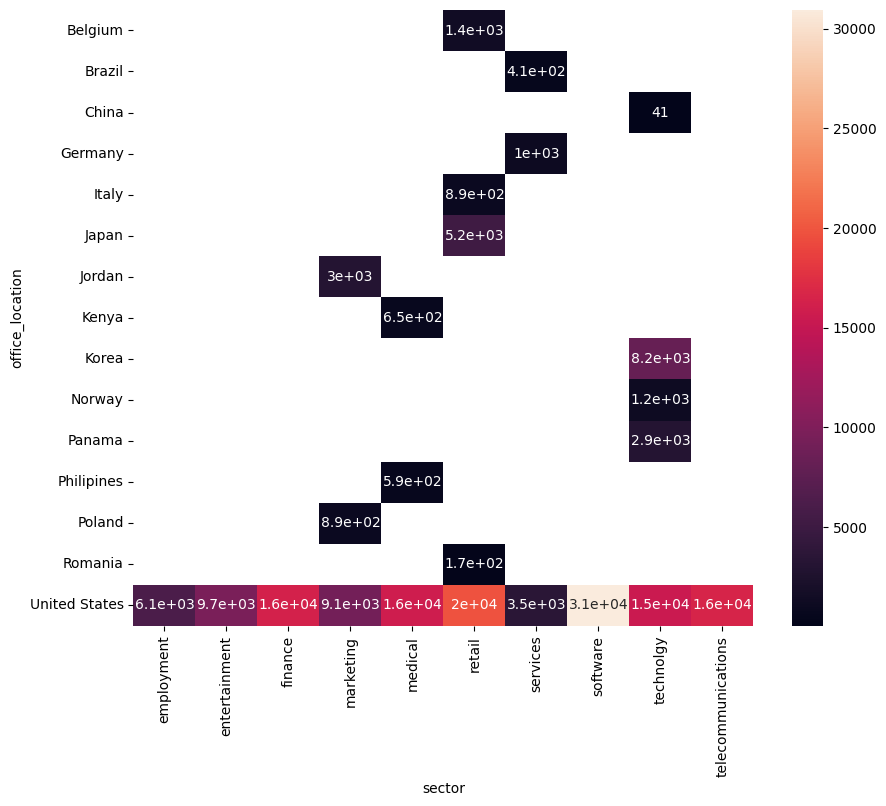

In [ ]:
#Employees by office_location and sector
plt.figure(figsize=(10,8))
loc_sec_rev = (acc.groupby(['office_location', 'sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
loc_sec_rev = loc_sec_rev[loc_sec_rev['revenue']!= 0]
print(loc_sec_rev)
#sns.heatmap(loc_sec_rev.pivot_table(index='office_location', columns='sector', values='revenue'), annot=True)


--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--
sector
retail                17
medical               12
technolgy             12
marketing              8
finance                8
software               7
telecommunications     6
entertainment          6
services               5
employment             4
dtype: int64


/tmp/ipython-input-456893921.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



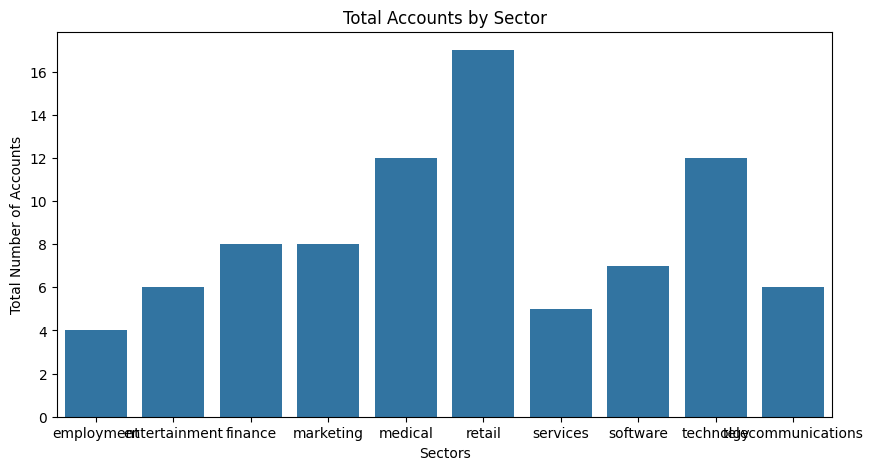

In [ ]:
#1.1 Total accounts by sectors
acc_by_sec = acc.groupby('sector').size().sort_values(ascending=False)
#print(acc['account'].value_counts())
print(f"--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--\n{acc_by_sec}")
plt.figure(figsize=(10,5))
sns.barplot(x=acc_by_sec.index, y=acc_by_sec.values)
plt.title('Total Accounts by Sector')
plt.xlabel('Sectors')
plt.ylabel('Total Number of Accounts')
plt.show()

In [ ]:
acc_tech= acc[acc['sector']=="technolgy"]
round(acc_tech.revenue.sum(), 2)

np.float64(27780.53)

In [ ]:
#average and sum of revenue by sector
rev_by_sec = acc.groupby('sector').agg({'revenue': ['sum', 'mean']}).round(2).sort_values(by=('revenue', 'sum'), ascending=False)
rev_by_sec
rev_by_sec.columns = ['total_revenue', 'average_revenue']
rev_by_sec

/tmp/ipython-input-3507518487.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,total_revenue,average_revenue
sector,,
software,30950.45,4421.49
technolgy,27780.53,2315.04
retail,27355.76,1609.16
medical,16976.88,1414.74
telecommunications,16461.91,2743.65
finance,16233.34,2029.17
marketing,13070.38,1633.80
entertainment,9665.22,1610.87
employment,6104.64,1526.16


In [ ]:
#acc
accL = acc.copy()
accR= acc.copy()
acc_main = accL.merge(accR, left_on='subsidiary_of', right_on='account', how='left')
#acc_main
#acc_main = acc.merge(acc, left_on='subsidiary_of', right_on='account', how='left')
#acc_main
#acc_main['main_acc'] = acc_main['subsidiary_of_y'].fillna(acc_main['account_x'])
#acc_main
acc_main['main_accn'] = acc_main['account_y'].fillna(acc_main['account_x'])
print(acc_main['main_accn'].value_counts().sum())
acc_main['main_accn'].value_counts().to_frame().reset_index()

85


,main_accn,count
0,Acme Corporation,5
1,Sonron,4
2,Inity,3
3,Golddex,3
4,Bubba Gump,3
...,...,...
65,Zathunicon,1
66,Zencorporation,1
67,Zoomit,1
68,Zotware,1


In [ ]:
#Total revenue by grouping account
revenue_by_account = acc_main.groupby('main_accn')['revenue_x'].sum().sort_values(ascending=False).reset_index()
revenue_by_account

,main_accn,revenue_x
0,Kan-code,11698.03
1,Sonron,8878.44
2,Hottechi,8170.38
3,Konex,7708.38
4,Xx-holding,7537.24
...,...,...
65,Domzoom,217.87
66,Sumace,167.89
67,Zathunicon,71.12
68,Zencorporation,40.79


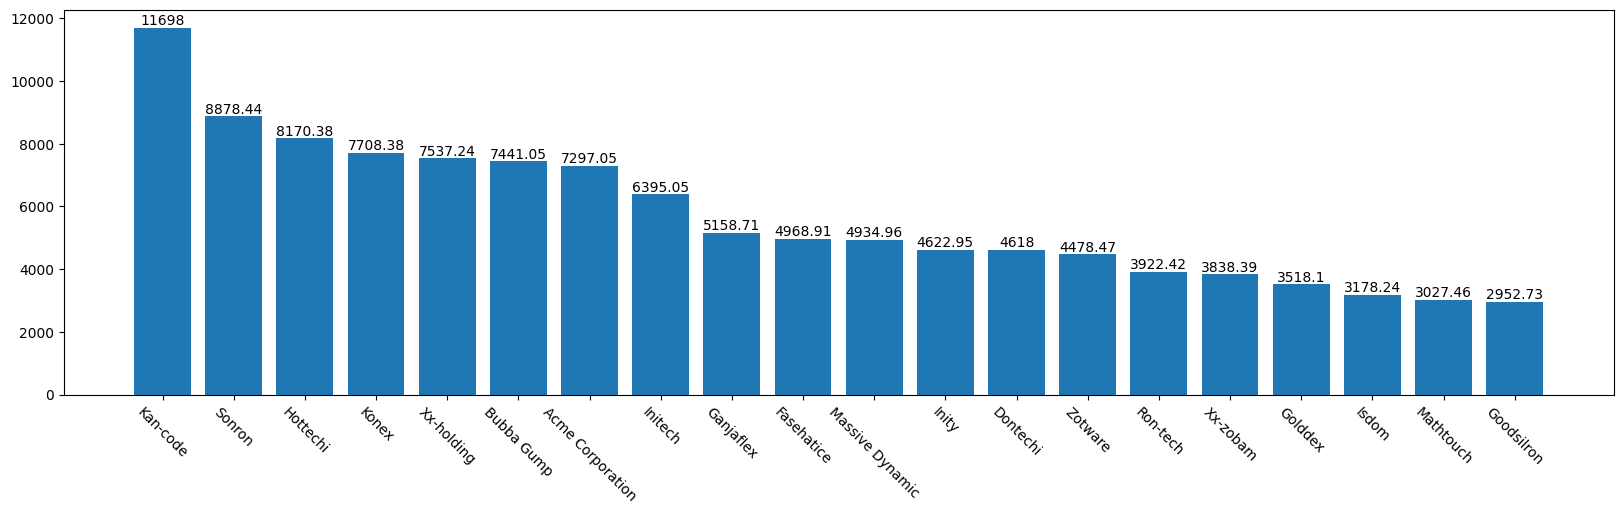

In [ ]:
plt.figure(figsize=(20,5))
top_10_acc_rev = revenue_by_account.head(20)
figure_ax2= plt.bar(top_10_acc_rev['main_accn'], top_10_acc_rev['revenue_x'])
plt.bar_label(figure_ax2)
plt.xticks(rotation=-45)
plt.show()

In [ ]:
#acc.info()

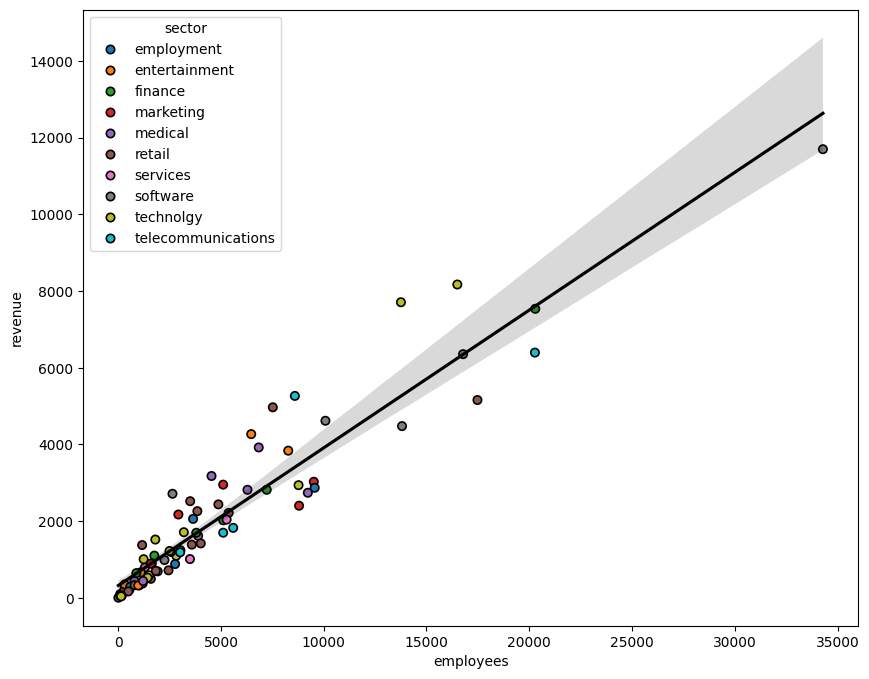



Correlation Cefficient between employees and revenue: 
[[1.         0.94608437]
 [0.94608437 1.        ]]


Coorelation between revenue and employees : 0.9460843747719687

p-value on hypothesis test: 2.1425602647004776e-42

 High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, 
and accept the alternative, that there exists a positive correlation between employees and revenue.


In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=acc['employees'], y=acc['revenue'], hue=acc['sector'], palette="tab10", edgecolor="black", linewidth=1.2)
sns.regplot(x=acc['employees'], y=acc['revenue'], scatter=False, color="black")
plt.show()
#Pearson Correlation Coefficient
print(f"\n\nCorrelation Cefficient between employees and revenue: \n{np.corrcoef(acc['employees'], acc['revenue'])}")

# Correlation test + hypothestsi testing
# Null hypothesis: there's no correlation between x and y variables
# Using Pearson's correlation test, assuming
# 1. Equal variable pairing, 2. Each variable is continuous, 3. No Outliers, 4. Linearity and homoscedastic
x= acc['employees']
y= acc['revenue']
print(f"\n\nCoorelation between revenue and employees : {scipy.stats.pearsonr(x,y)[0]}")
print(f"\np-value on hypothesis test: {scipy.stats.pearsonr(x,y)[1]}")
print("\n High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, \nand accept the alternative, that there exists a positive correlation between employees and revenue.")


In [ ]:
#acc['year_established'].value_counts().sort_index(ascending=True)
rev_year = acc.groupby(['year_established'])['revenue'].sum().reset_index()
rev_year

,year_established,revenue
0,1979,4478.47
1,1980,7708.38
2,1982,17108.49
3,1983,3879.41
4,1984,3468.54
5,1985,3116.80
6,1986,3050.76
7,1987,5042.46
8,1988,8702.79
9,1989,5892.12


Total revenue has been decreasing over time with 
 with surge in 1990, with a dip in 1991 with increase in 1993 
 with slow decline. No trace of revenue following 2013 to 2016


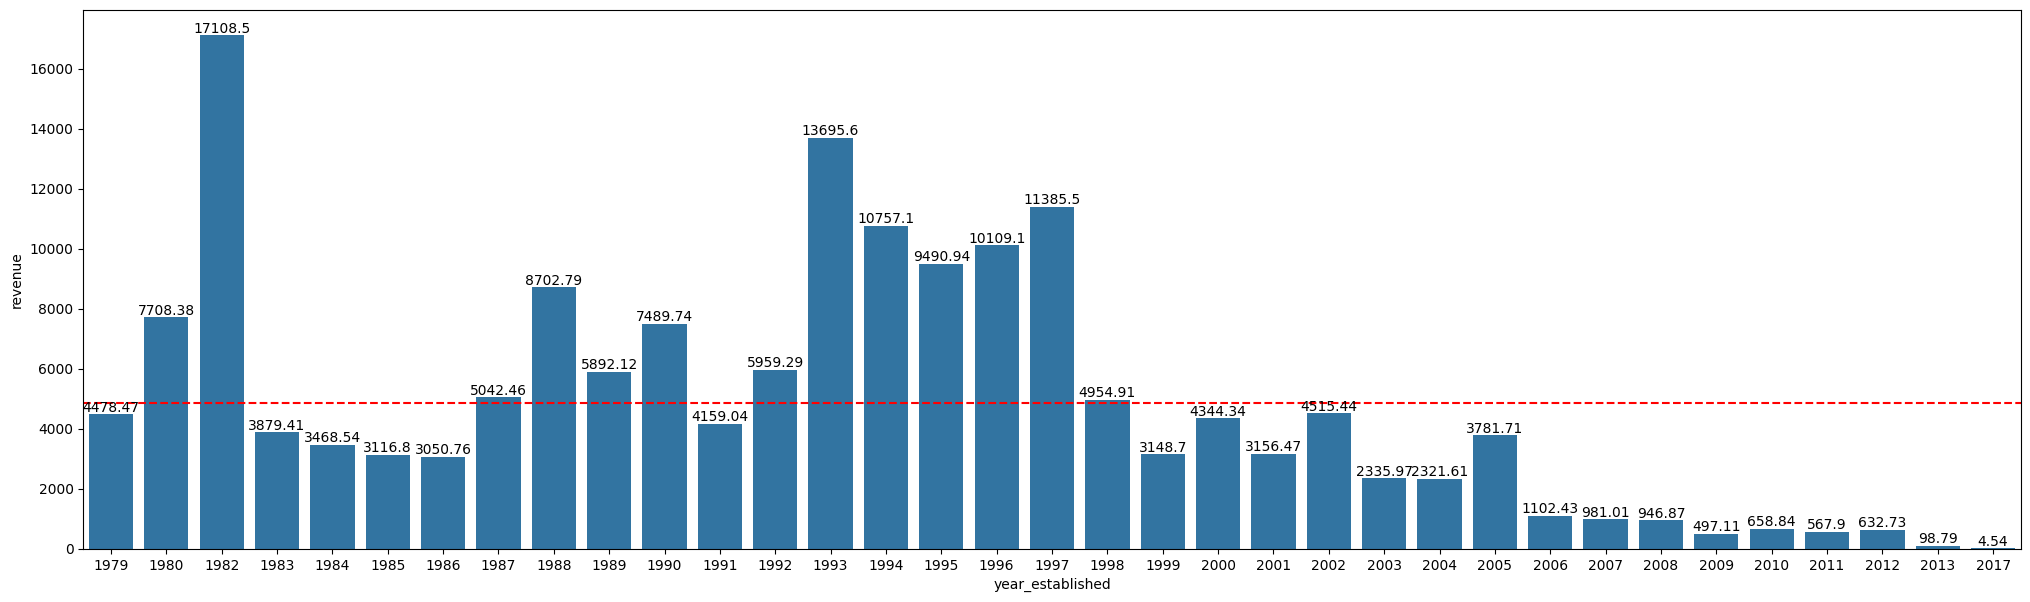

In [ ]:
plt.figure(figsize=(25,7))
avg_year_rev = rev_year['revenue'].mean()
ax_figue1 = sns.barplot(x='year_established', y='revenue', data= rev_year)
print("Total revenue has been decreasing over time with \n with surge in 1990, with a dip in 1991 with increase in 1993 \n with slow decline. No trace of revenue following 2013 to 2016")
ax_figue1.bar_label(ax_figue1.containers[0])
plt.axhline(y=avg_year_rev, color='red', linestyle='--', label=avg_year_rev)

In [ ]:
rev_by_sec

,total_revenue,average_revenue
sector,,
software,30950.45,4421.49
technolgy,27780.53,2315.04
retail,27355.76,1609.16
medical,16976.88,1414.74
telecommunications,16461.91,2743.65
finance,16233.34,2029.17
marketing,13070.38,1633.80
entertainment,9665.22,1610.87
employment,6104.64,1526.16


Avg Revenue Overall = 2029.3



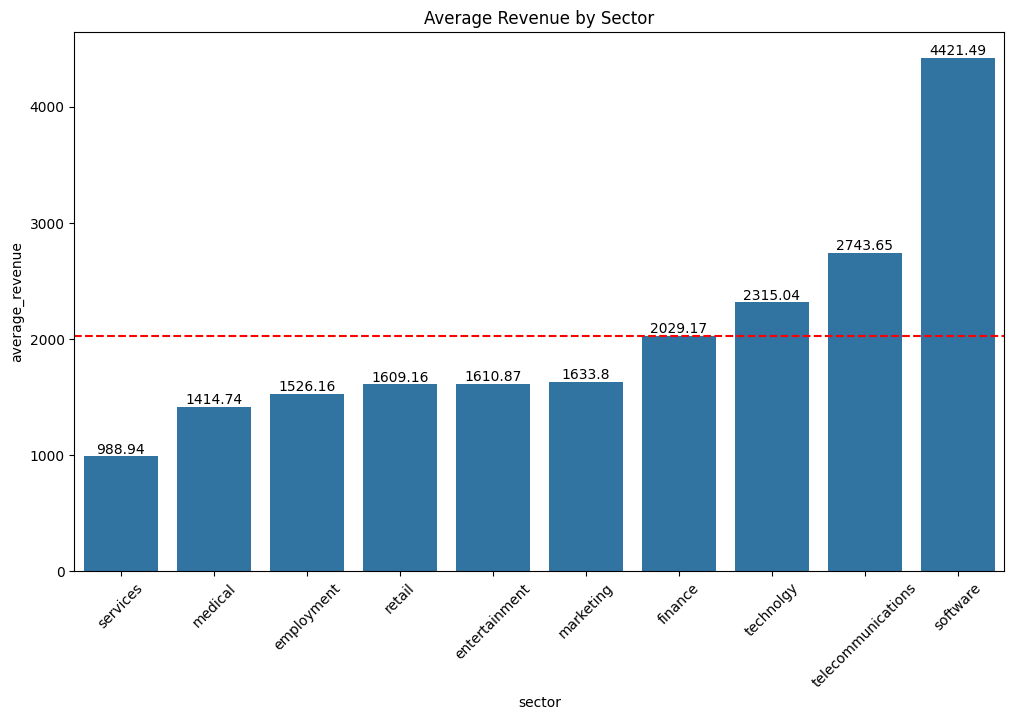

In [ ]:
#Adding an avg line
avg_rev_accn = rev_by_sec['average_revenue'].mean().round(2)
print(f"Avg Revenue Overall = {avg_rev_accn}\n")

#bar plot with avg line
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=rev_by_sec,
    x='sector',
    y='average_revenue',
    order=rev_by_sec.sort_values(by="average_revenue", ascending = True).index
)
plt.title('Average Revenue by Sector')
ax.bar_label(ax.containers[0])
plt.axhline(y=avg_rev_accn, color='red', linestyle='--', label=avg_rev_accn)
plt.xticks(rotation=45)  # if sector names are long
plt.show()

In [ ]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


## Sales Pipeline